# Titanic Survival Prediction

This notebook builds a machine learning model to predict which passengers survived the Titanic disaster, using the classic [Kaggle Titanic competition](https://www.kaggle.com/c/titanic) dataset.

## Overview
The workflow covers:
1. **Enviornment Setup** — import core libraries used in project
2. **Data Loading** — read the training and test CSV files.
3. **Exploratory Data Analysis (EDA)** — examine survival rates by gender, visualize missing data, and analyze the relationship between survival and passenger class or family size.
4. **Feature Engineering** — impute missing values for `Age` and `Fare`; create new categorical features (`CatAge`, `FamilySize`, `FareCat`, `PclassCat`, `FarePerPerson`) and one‑hot encode them.
5. **Model Training** — train a **Decision Tree** classifier and compare its performance with **Logistic Regression**.
6. **Submission** — use the Decision Tree model to predict survival on the test set and save the results to `submission.csv`.
7. **Things to add** — data Analysis that could have been added to the Project

The Decision Tree model achieved a validation accuracy of **~80.4%** and a precision score of **0.79**.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('Data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Data\gender_submission.csv
Data\test.csv
Data\train.csv


## 1. Environment Setup

Import core libraries that are used inside project (`numpy`, `pandas`, `seaborn1`, `matplotlib`, `scikit-learn`)

In [2]:
# For example, here's several helpful packages to load

# This Python 3 environment comes with many helpful analytics libraries installed
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# For nicer visuals
%matplotlib inline
sns.set_style('whitegrid')


## 2. Data Loading

Load the training and test datasets. The training set contains 891 passengers with known survival labels; the test set contains 418 passengers whose survival we need to predict.

In [3]:
train_data = pd.read_csv("Data/train.csv")
print(train_data.head())
train_data.PassengerId


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


0        1
1        2
2        3
3        4
4        5
      ... 
886    887
887    888
888    889
889    890
890    891
Name: PassengerId, Length: 891, dtype: int64

In [4]:

test_data = pd.read_csv("Data/test.csv")
print(test_data.head())
test_data.PassengerId

   PassengerId  Pclass                                          Name     Sex  \
0          892       3                              Kelly, Mr. James    male   
1          893       3              Wilkes, Mrs. James (Ellen Needs)  female   
2          894       2                     Myles, Mr. Thomas Francis    male   
3          895       3                              Wirz, Mr. Albert    male   
4          896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female   

    Age  SibSp  Parch   Ticket     Fare Cabin Embarked  
0  34.5      0      0   330911   7.8292   NaN        Q  
1  47.0      1      0   363272   7.0000   NaN        S  
2  62.0      0      0   240276   9.6875   NaN        Q  
3  27.0      0      0   315154   8.6625   NaN        S  
4  22.0      1      1  3101298  12.2875   NaN        S  


0       892
1       893
2       894
3       895
4       896
       ... 
413    1305
414    1306
415    1307
416    1308
417    1309
Name: PassengerId, Length: 418, dtype: int64

## 3. Exploratory Data Analysis (EDA)

### 3a. Survival Rates by Gender

The "women and children first" evacuation policy suggests gender is a strong predictor of survival. We calculate the raw survival rate for female and male passengers separately.

In [5]:
women = train_data.loc[train_data.Sex == 'female']["Survived"]
rate_women = sum(women)/len(women)

print("% of women who survived:", rate_women)

% of women who survived: 0.7420382165605095


In [6]:
men = train_data.loc[train_data.Sex == 'male']["Survived"]
rate_men = sum(men)/len(men)

print("% of men who survived:", rate_men)

% of men who survived: 0.18890814558058924


### 3b. Missing Value Analysis

Identify columns with missing data that will need imputation before modeling. Key columns with missing values are `Age`, `Fare`, and `Cabin`.

          Train   Test
Age         177   86.0
Cabin       687  327.0
Embarked      2    0.0
Fare          0    1.0


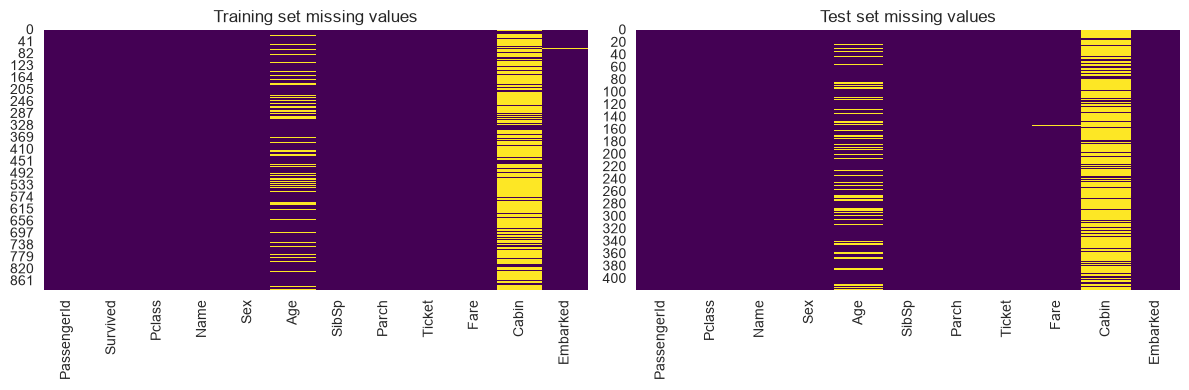

In [7]:
# Check missing values in train and test
missing_train = train_data.isnull().sum()
missing_test = test_data.isnull().sum()
missing_df = pd.DataFrame({'Train': missing_train, 'Test': missing_test})
print(missing_df[missing_df.sum(axis=1) > 0])

# Plot missingness
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.heatmap(train_data.isnull(), cbar=False, ax=axes[0], cmap='viridis')
axes[0].set_title('Training set missing values')
sns.heatmap(test_data.isnull(), cbar=False, ax=axes[1], cmap='viridis')
axes[1].set_title('Test set missing values')
plt.tight_layout()
plt.show()

### 3c. Survival by Passenger Class

A histogram faceted by survival status shows how passenger class (1st, 2nd, 3rd) correlates with survival. First-class passengers had significantly higher survival rates.

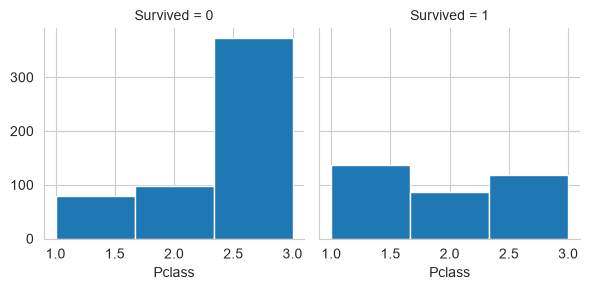

In [8]:
g = sns.FacetGrid(train_data, col='Survived')
g.map(plt.hist, 'Pclass', bins=3)


### 3d. Survival by Number of Parents/Children (Parch)

Passengers traveling with 1–3 family members (parents or children) had notably higher survival rates than solo travelers or those in very large family groups.

In [9]:
train_data[["Parch", "Survived"]].groupby(['Parch'], as_index=False).mean().sort_values(by='Survived', ascending=False)


,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


## 4. Feature Engineering & Model Training

Impute missing `Age` and `Fare` values with the median, then engineer categorical features:
- **CatAge** — age bins (infant, child, young, grownup, oldest survivor)
- **FamilySize** — total family members, bucketed into NoFamily / SmallFamily / BigFamily
- **FareCat** — fare quartile buckets
- **PclassCat** — passenger class as an ordered category
- **FarePerPerson**: Fare divided by family size (to account for group discounts).


### 4a.Missing value imputation
We impute missing `Age` and `Fare` values with the median computed from the training set. The same imputers are later applied to the test set.

we ignore Cabin missing Data since a lot of the data is missing and we are not gonna use it in our model

In [10]:
imputer_age = SimpleImputer(strategy='median')
imputer_fare = SimpleImputer(strategy='median')

train_data['Age'] = imputer_age.fit_transform(train_data[['Age']])
train_data['Fare'] = imputer_fare.fit_transform(train_data[['Fare']])

test_data['Age'] = imputer_age.transform(test_data[['Age']])
test_data['Fare'] = imputer_fare.transform(test_data[['Fare']])

### 4b.Feature Engineering
We create several new categorical features from existing ones:
- **CatAge**: Age groups (infant, child, young, grownup, oldest survivor).
- **FamilySize**: Binned total family size (NoFamily, SmallFamily, BigFamily).
- **FareCat**: Fare quartile bins (based on training data quartiles).
- **PclassCat**: Passenger class as an ordered category.
- **FarePerPerson**: Fare divided by family size (to account for group discounts).

The same bin boundaries from the training set are reused for the test set.

In [11]:
# Age bins
train_data['CatAge'] = pd.cut(train_data['Age'],
                              bins=[0, 4, 16, 40, 75, 85],
                              labels=['infant', 'child', 'young', 'grownup', 'oldest survivor'],
                              right=True)

# Family size – raw and binned
train_data['FamilySize_raw'] = train_data['SibSp'] + train_data['Parch']
train_data['FamilySize'] = pd.cut(train_data['FamilySize_raw'],
                                  bins=[-1, 0, 3, 40],
                                  labels=['NoFamily', 'SmallFamily', 'BigFamily'],
                                  right=True)

# ----- Fare bins based on quartiles from training data -----
q1 = train_data['Fare'].quantile(0.25)
q2 = train_data['Fare'].quantile(0.50)
q3 = train_data['Fare'].quantile(0.75)

min_fare = train_data['Fare'].min() - 1e-6
max_fare = train_data['Fare'].max() + 1e-6
bins_fare = [min_fare, q1, q2, q3, max_fare]
labels_fare = ['cheapFare', 'mediumFare', 'medhighFare', 'expensiveFare']

train_data['FareCat'] = pd.cut(train_data['Fare'],
                               bins=bins_fare,
                               labels=labels_fare,
                               right=True)

# Pclass as ordered category
train_data['PclassCat'] = pd.cut(train_data['Pclass'],
                                 bins=[0, 1, 2, 3],
                                 labels=['1', '2', '3'],
                                 right=True)

# Fare per person (avoids division by zero)
train_data['FarePerPerson'] = train_data['Fare'] / (train_data['FamilySize_raw'] + 1)

# 3. Feature engineering for TEST (must match training columns)
test_data['CatAge'] = pd.cut(test_data['Age'],
                             bins=[0, 4, 16, 40, 75, 85],
                             labels=['infant', 'child', 'young', 'grownup', 'oldest survivor'],
                             right=True)

test_data['FamilySize_raw'] = test_data['SibSp'] + test_data['Parch']
test_data['FamilySize'] = pd.cut(test_data['FamilySize_raw'],
                                 bins=[-1, 0, 3, 40],
                                 labels=['NoFamily', 'SmallFamily', 'BigFamily'],
                                 right=True)

# Apply the SAME quartile bins from training to test
test_data['FareCat'] = pd.cut(test_data['Fare'],
                              bins=bins_fare,
                              labels=labels_fare,
                              right=True)

test_data['PclassCat'] = pd.cut(test_data['Pclass'],
                                bins=[0, 1, 2, 3],
                                labels=['1', '2', '3'],
                                right=True)

test_data['FarePerPerson'] = test_data['Fare'] / (test_data['FamilySize_raw'] + 1)

### 4c.Encoding Categorical Variables and Aligning Test Set
We one‑hot encode all categorical features. To ensure the test set has the same dummy columns as the training set, we `reindex` with `fill_value=0`

In [12]:
# Select features for modeling
train_features = train_data[['PclassCat', 'Sex', 'CatAge', 'FamilySize', 'FareCat',
                             'Embarked', 'FarePerPerson']]
test_features = test_data[['PclassCat', 'Sex', 'CatAge', 'FamilySize', 'FareCat',
                           'Embarked', 'FarePerPerson']]

# One‑hot encode
X = pd.get_dummies(train_features)
y = train_data['Survived']

X_test = pd.get_dummies(test_features)

# Align test columns with training columns (fill missing with 0)
X_test = X_test.reindex(columns=X.columns, fill_value=0)

## 5.Model Training
All categorical features are one-hot encoded with `pd.get_dummies`. A **Decision Tree** classifier is trained and validated (80/20 split), and its feature importances are reported. A **Logistic Regression** model is also fitted for comparison. Finally, predictions on the test set are written to `submission.csv`.

### 5a.Model Training – Decision Tree
We split the training data into training and validation sets (80/20). A Decision Tree classifier is trained and evaluated. We also plot feature importances to see which features contributed most.

Decision Tree Validation Accuracy: 0.8045


C:\Users\hp\AppData\Local\Temp\ipykernel_25060\2019493101.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')


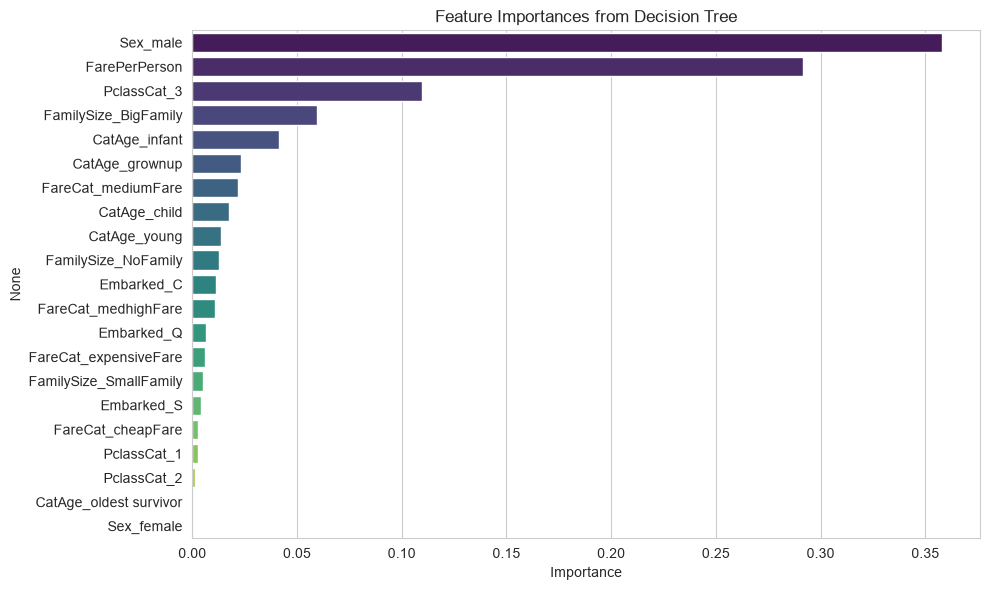

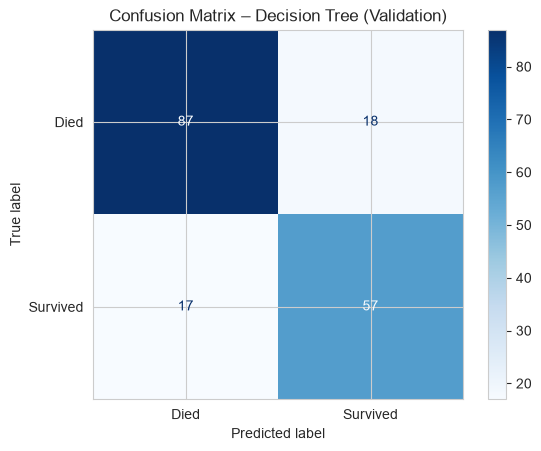

In [13]:
# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
print(f"Decision Tree Validation Accuracy: {accuracy_score(y_val, y_pred):.4f}")

# --- Feature Importance Plot ---
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')
plt.title('Feature Importances from Decision Tree')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# --- Confusion Matrix ---
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix – Decision Tree (Validation)')
plt.show()

### 5b.Logistic Regression for Comparison
We fit a Logistic Regression model on the same training data and compare its validation accuracy. We also show its confusion matrix.

Logistic Regression Validation Accuracy: 0.7989


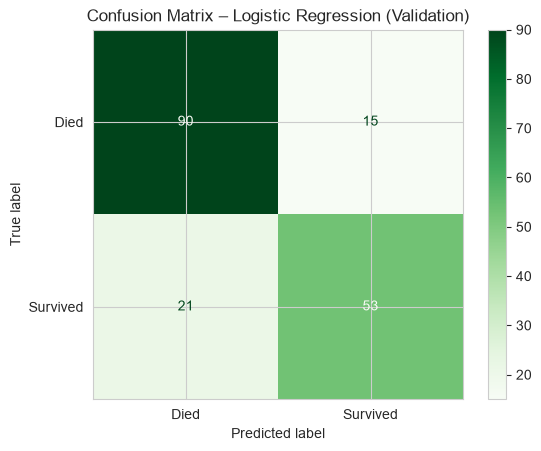

In [14]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_val)
print(f"Logistic Regression Validation Accuracy: {accuracy_score(y_val, lr_pred):.4f}")

# Confusion Matrix
cm_lr = confusion_matrix(y_val, lr_pred)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Died', 'Survived'])
disp_lr.plot(cmap='Greens')
plt.title('Confusion Matrix – Logistic Regression (Validation)')
plt.show()

### 6.Generate Submission
Finally, we use the Decision Tree model (or Logistic Regression, if preferred) to predict survival on the test set and save the results to `submission.csv`.

In [15]:
# Use the Decision Tree model for submission
predictions = model.predict(X_test)
output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': predictions})
output.to_csv('submission.csv', index=False)
print("Submission saved as 'submission.csv'")

Submission saved as 'submission.csv'


## 7.things that could've been added
even though the Cabin Data was missing a lot of values we still could've trued to use it in our Models by only using the available data

each passenger had a title to their name which we couldve extracted and used (if a man had the title Master the chances of him survivng would've definitly been higher)

by changing the Category variables and values we might have been able to get better results

we could have used different imputation strategies